<a href="https://colab.research.google.com/github/Rominaarab/Machine-learning/blob/main/Thesis_Final_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install R in Colab
!apt-get update -qq
!apt-get install -y r-base r-base-dev

# Set R environment
import os
os.environ['R_HOME'] = '/usr/lib/R'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base-dev is already the newest version (4.5.1-1.2204.0).
r-base is already the newest version (4.5.1-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.


In [1]:
import pandas as pd
import numpy as np
import requests
import gzip
import io
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.decomposition import PCA
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from openpyxl import load_workbook
import warnings
warnings.filterwarnings('ignore')

# For R integration (GSVA)
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import StrVector
import rpy2.robjects.packages as rpackages

# Activate pandas-R interface
pandas2ri.activate()

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import Tensor

In [2]:
class CompleteDataAcquisition:
    def __init__(self, data_dir="./nsclc_data"):

        self.data_dir = Path(data_dir)
        self.data_dir.mkdir(exist_ok=True)

        # Define gene sets based on your specifications

        self.mirna = [
            'hsa-mir-155', 'hsa-mir-21', 'hsa-mir-34a', 'hsa-mir-146b', 'hsa-mir-326',
            'hsa-mir-149', 'hsa-mir-195', 'hsa-mir-365', 'hsa-mir-15a', 'let-7',
            ]

        self.circrnas = ['hsa-TP63_0006', 'hsa-SPECC1L-ADORA2A_0027', 'hsa-NEIL3_0001']
        self.lncrnas = ['MALAT1', 'HOTAIR', 'NEAT1', 'LINC00467', 'LINC00665', 'LINC00460',
                        'XIST', 'H19', 'MEG3', 'ALMS1-IT1', 'ANRIL']

        self.metabolic_genes = [
            'HK2', 'GPI', 'PFKM', 'ALDOA', 'TPI1', 'GAPDH', 'PGK1', 'ENO1', 'PKM',  # Glycolysis
            'ARG1', 'ARG2', 'ASS1', 'ASL', 'OTC', 'CPS1',  # Arginine
            'IDO1', 'IDO2', 'TDO2', 'KYNU', 'KMO', 'HAAO',  # Tryptophan
            'GLS', 'GLS2', 'GLUD1', 'GLUL', 'SLC1A5'  # Glutamine
        ]

        self.immune_genes = [
            'CD274', 'PDCD1', 'CTLA4', 'LAG3', 'TIGIT',
            'HAVCR2', 'VSIR', 'BTLA', 'CD276', 'ICOS'
        ]

        self.m6a_gene_list = [
            'METTL3', 'METTL14', 'WTAP', 'KIAA1429', 'RBM15',  # Writers
            'FTO', 'ALKBH5',  # Erasers
            'YTHDF1', 'YTHDF2', 'YTHDC1', 'HNRNPC', 'IGF2BP1', 'IGF2BP2', 'IGF2BP3'  # Readers
        ]  # to gather all m6a corrolated with nsclc

    def download_file(self, url, filename, description="file"):
        """Download file with error handling"""
        print(f"📥 Downloading {description}...")
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()

            filepath = self.data_dir / filename
            with open(filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"✅ {description} downloaded: {filepath}")
            return filepath
        except Exception as e:
            print(f"❌ Error downloading {description}: {e}")
            return None

    def get_tcga_rna_seq(self):
        """Download TCGA LUAD RNA-seq data"""
        print("\n🧬 Acquiring TCGA LUAD RNA-seq Data...")

        hub = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.LUAD.sampleMap%2FHiSeqV2.gz"

        filepath = self.download_file(hub, "TCGA_LUAD_HiSeqV2.gz", "TCGA LUAD RNA-seq")

        if filepath:
            # Load and process the data
            try:
                with gzip.open(filepath, 'rt') as f:
                    rna_seq_df = pd.read_csv(f, sep='\t', index_col=0)
                print(f"✅ RNA-seq loaded: {rna_seq_df.shape}")

                # Filter for your target genes
                all_target_genes = self.metabolic_genes + self.immune_genes + self.m6a_gene_list
                found_genes = [gene for gene in all_target_genes if gene in rna_seq_df.index]

                if found_genes:
                    filtered_rna = rna_seq_df.loc[found_genes]
                    print(f"✅ Target genes found: {len(found_genes)}/{len(all_target_genes)}")
                    return filtered_rna
                else:
                    print("⚠️  No target genes found in RNA-seq data")
                    return rna_seq_df

            except Exception as e:
                print(f"❌ Error loading RNA-seq: {e}")
                return None
        return None

    def get_mirna_data(self):
        mi_url = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-LUAD.mirna.tsv.gz"
        filepath = self.download_file(mi_url, "TCGA-LUAD.mirna.tsv.gz", "TCGA-LUAD.mirna.tsv")
        if filepath:
            try:
                with gzip.open(filepath, 'rt') as f:
                    gene_df = pd.read_csv(f, sep='\t', index_col=0)
                print(f"✅ Gene data loaded: {gene_df.shape}")

                # Filter for target genes
                found_genes = [gene for gene in self.mirna if gene in gene_df.index]
                if found_genes:
                    filtered_df = gene_df.loc[found_genes]
                    print(f"✅ Target genes found: {len(found_genes)}/{len(self.mirna)}")
                    return filtered_df
                else:
                    print("⚠️ No target genes found. Returning None.")
                    return None
            except Exception as e:
                print(f"❌ Error loading gene data: {e}")
                return None
        return None

    from openpyxl import load_workbook
    def create_circrna_data(self):
        circ_path = load_workbook(filename='/content/Suppl Table S2 circRNA data gene level.xlsx')
        sheet = circ_path['Table S2']
        data = sheet.values
        # Read the first row to check if it's the header
        first_row = next(data)
        # Assuming the actual header is the next row (or you can visually inspect the file)
        # Skip the first row which contains descriptive text
        actual_header = next(data) # Read the second row as header
        columns = actual_header # Use the second row values as columns

        # Read the remaining data using the identified columns
        circ_df = pd.DataFrame(list(data), columns=columns)

        # Handle potential None column names if the header row had empty cells
        circ_df.columns = [f'Col_{i}' if col is None else col for i, col in enumerate(circ_df.columns)]

        print(f"✅ circRNA data loaded: {circ_df.shape}")
        # print(f"circRNA columns: {circ_df.columns.tolist()}") # Uncomment to inspect columns
        # print(f"circRNA head:\n{circ_df.head()}") # Uncomment to inspect head
        return circ_df # Return the DataFrame

    def get_lncrna_data(self):
        gene_url = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.LUAD.sampleMap%2FHiSeqV2.gz"
        filepath = self.download_file(gene_url, "TCGA_LUAD_GeneExpression.gz", "TCGA LUAD Gene Expression")
        if filepath:
            try:
                with gzip.open(filepath, 'rt') as f:
                    gene_df = pd.read_csv(f, sep='\t', index_col=0)
                print(f"✅ Gene data loaded: {gene_df.shape}")

                # Filter for target genes
                found_genes = [gene for gene in self.lncrnas if gene in gene_df.index]
                if found_genes:
                    filtered_df = gene_df.loc[found_genes]
                    print(f"✅ Target genes found: {len(found_genes)}/{len(self.lncrnas)}")
                    return filtered_df
                else:
                    print("⚠️ No target genes found. Returning None.")
                    return None
            except Exception as e:
                print(f"❌ Error loading gene data: {e}")
                return None
        return None

    def get_gse135222_data(self):
        """Download GSE135222 immunotherapy response data"""
        print("\n💊 Acquiring GSE135222 Immunotherapy Data...")

        # Expression data
        expr_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE135nnn/GSE135222/suppl/GSE135222%5FGEO%5FRNA%2Dseq%5Fomicslab%5Fexp.tsv.gz"

        expr_filepath = self.download_file(expr_url, "GSE135222_GEO_RNA-seq_omicslab_exp.tsv.gz")
        data_dict = {}

        # Load expression data
        if expr_filepath:
            try:
                with gzip.open(expr_filepath, 'rt') as f:
                    expr_data = pd.read_csv(f, sep='\t', index_col=0)
                data_dict['expression'] = expr_data
                print(f"✅ GSE135222 expression: {expr_data.shape}")
            except Exception as e:
                print(f"❌ Error loading GSE135222 expression: {e}")

        # Clinical/metadata
        clinical_path = "/content/clinical.tsv"
        if clinical_path:
          try:
            clinical_df = pd.read_csv(clinical_path, sep='\t')
            print(f"✅ Clinical data loaded: {clinical_df.shape}")
            data_dict['clinical'] = clinical_df # Add clinical data to the dictionary
          except FileNotFoundError:
            print(f"❌ Error: Clinical file not found at {clinical_path}")
            return None
          except Exception as e:
            print(f"❌ Error reading clinical data: {e}")
            return None

        # Return the dictionary containing both expression and clinical data
        if data_dict:
             return data_dict
        else:
             return None

In [3]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
from typing import Optional, Dict, Any # Import Any here

In [4]:
class DataPreprocessor:
    def __init__(self):
        self.imputers = {}
        self.scalers = {}

    def quality_check(self, data, name):
        """Quick quality assessment"""
        print(f"\n🔍 Quality Check: {name}")
        print(f"Shape: {data.shape}")
        print(f"Missing values: {data.isnull().sum().sum()}")
        print(f"Data type: {data.dtypes.value_counts().to_dict()}")

    def filter_low_variance(self, data, threshold=0.01):
        """Remove low variance genes"""
        # Ensure data is numeric before calculating variance
        numeric_data = data.select_dtypes(include=np.number)

        variance = numeric_data.var(axis=1)
        high_var_mask = variance > threshold
        # Apply mask to the original data to keep non-numeric columns if needed later
        filtered_data = data.loc[high_var_mask.index[high_var_mask]]

        removed = data.shape[0] - filtered_data.shape[0]
        print(f"🔽 Removed {removed} low variance genes")
        return filtered_data

    def knn_imputation(self, data, name, n_neighbors=5):
        """Perform KNN imputation on numeric columns"""
        print(f"🔧 KNN Imputation: {name}")

        # Select only numeric columns for imputation
        numeric_data = data.select_dtypes(include=np.number)

        missing_before = numeric_data.isnull().sum().sum()
        if missing_before == 0:
            print("No missing values in numeric columns")
            return data # Return original data if no missing numeric values

        if numeric_data.empty:
            print(f"⚠️ No numeric columns to impute in {name}")
            return data # Return original data if no numeric columns

        # Transpose for imputation (samples x genes)
        numeric_data_t = numeric_data.T

        # Perform KNN imputation
        imputer = KNNImputer(n_neighbors=n_neighbors)
        imputed_data_t = imputer.fit_transform(numeric_data_t)

        # Transpose back and create DataFrame with original index/columns
        imputed_numeric_data = pd.DataFrame(imputed_data_t.T, index=numeric_data.index, columns=numeric_data.columns)

        # Combine imputed numeric data with original non-numeric data
        non_numeric_data = data.select_dtypes(exclude=np.number)
        if not non_numeric_data.empty:
            imputed_data = pd.concat([imputed_numeric_data, non_numeric_data], axis=1)
        else:
            imputed_data = imputed_numeric_data


        missing_after = imputed_data.isnull().sum().sum()
        print(f"✅ Missing values: {missing_before} → {missing_after}")

        self.imputers[name] = imputer
        return imputed_data

    def z_score_normalize(self, data, name, method='gene_wise'):
        """Apply Z-score normalization to numeric columns"""
        print(f"📊 Z-score Normalization: {name} ({method})")

        # Select only numeric columns for normalization
        numeric_data = data.select_dtypes(include=np.number)

        if numeric_data.empty:
            print(f"⚠️ No numeric columns to normalize in {name}")
            return data # Return original data if no numeric columns

        if method == 'gene_wise':
            normalized_numeric = numeric_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        elif method == 'sample_wise':
            normalized_numeric = numeric_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        else:
            print(f"⚠️ Unknown normalization method: {method}. Skipping normalization.")
            return data # Return original data if method is unknown

        # Handle NaN/inf in normalized numeric data
        normalized_numeric = normalized_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)

        # Combine normalized numeric data with original non-numeric data
        non_numeric_data = data.select_dtypes(exclude=np.number)
        if not non_numeric_data.empty:
            normalized_data = pd.concat([normalized_numeric, non_numeric_data], axis=1)
        else:
            normalized_data = normalized_numeric


        print(f"✅ Mean (numeric): {normalized_numeric.mean().mean():.3f}, Std (numeric): {normalized_numeric.std().mean():.3f}")
        return normalized_data

    def preprocess_dataset(self, data, name):
        """Complete preprocessing pipeline for a dataset"""
        print(f"\n{'='*50}")
        print(f"🚀 PREPROCESSING: {name}")
        print(f"{'='*50}")

        if data is None or data.empty:
            print(f"⚠️ Skipping preprocessing for {name}: Data is None or empty.")
            return data

        # Step 1: Quality check
        self.quality_check(data, name)

        # Step 2: Filter low variance (applied to numeric columns)
        # This step will now handle non-numeric columns by returning them along with filtered numeric columns
        data = self.filter_low_variance(data)

        # Step 3: KNN imputation (applied only to numeric columns)
        # This step will now handle non-numeric columns by returning them along with imputed numeric columns
        data = self.knn_imputation(data, name)

        # Step 4: Z-score normalization (applied only to numeric columns)
        # This step will now handle non-numeric columns by returning them along with normalized numeric columns
        data = self.z_score_normalize(data, name)

        print(f"✅ {name} preprocessing complete: {data.shape}")
        return data

    def handle_missing_values(self, data: pd.DataFrame, name: str, strategy: str = 'mean') -> pd.DataFrame:
        """Impute missing values for different data types."""
        print(f"🔧 Handling missing values for {name}...")
        processed_data = data.copy()

        if processed_data.isnull().sum().sum() == 0:
            print(f"No missing values found in {name}.")
            return processed_data

        # Separate columns by type for appropriate imputation
        categorical_cols = processed_data.select_dtypes(include=['object', 'category']).columns
        numeric_cols = processed_data.select_dtypes(include=np.number).columns

        # Impute categorical columns using 'most_frequent' or a specified strategy
        if not categorical_cols.empty:
            print(f"  Imputing categorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}...")
            cat_strategy = 'most_frequent' if strategy not in ['mean', 'median'] else strategy # Default for categorical
            categorical_imputer = SimpleImputer(strategy=cat_strategy)
            processed_data[categorical_cols] = categorical_imputer.fit_transform(processed_data[categorical_cols])
            self.imputers[f'{name}_categorical'] = categorical_imputer

        # Impute numeric columns (if any) - can use mean/median/knn depending on data
        if not numeric_cols.empty:
            print(f"  Imputing numeric columns ({len(numeric_cols)}): {numeric_cols.tolist()}...")
            num_strategy = 'mean' if strategy in ['most_frequent', 'constant'] else strategy # Default for numeric
            # Select only numeric columns with missing values for imputation
            numeric_cols_with_missing = processed_data[numeric_cols].columns[processed_data[numeric_cols].isnull().any()].tolist()

            if not numeric_cols_with_missing:
                print("    No numeric columns with missing values to impute.")
            else:
                print(f"    Numeric columns with missing values to impute: {numeric_cols_with_missing}")
                numeric_imputer = SimpleImputer(strategy=num_strategy)
                imputed_numeric_data = numeric_imputer.fit_transform(processed_data[numeric_cols_with_missing])
                processed_data[numeric_cols_with_missing] = imputed_numeric_data
                self.imputers[f'{name}_numeric'] = numeric_imputer


        print(f"✅ Missing values handled for {name}. New missing values count: {processed_data.isnull().sum().sum()}")
        return processed_data


    # Removed encode_categorical and vectorize_text methods as per user request


    def process_circrna(self, circrna_df: pd.DataFrame) -> pd.DataFrame:
        """Process circRNA data using only imputation."""
        print("\n--- Processing circRNA Data ---")
        if circrna_df is None or circrna_df.empty:
            print("⚠️ circRNA data is None or empty. Skipping processing.")
            return None

        processed_circrna = circrna_df.copy()

        # Assuming the first two columns 'Gene ID' and 'Gene Name' might need special handling or removal
        # Based on the previous error, these columns caused issues when treated as numeric.
        # Let's explicitly drop them or handle them as non-numeric if they are not intended as features.
        # If they are identifiers, they might be set as index or dropped.
        # Assuming they are identifiers and will be dropped for downstream numeric analysis.

        cols_to_drop_if_exist = ['Gene ID', 'Gene Name']
        for col in cols_to_drop_if_exist:
            if col in processed_circrna.columns:
                print(f"Dropping identifier column: '{col}'")
                processed_circrna = processed_circrna.drop(columns=[col])

        # Handle missing values for circRNA data
        processed_circrna = self.handle_missing_values(processed_circrna, "circRNA", strategy='mean')

        # Ensure all remaining columns are numeric
        # Keep this for circRNA if it's expected to be purely numeric features
        processed_circrna = processed_circrna.select_dtypes(include=np.number)

        if not processed_circrna.empty:
             print(f"✅ circRNA data processing complete. Shape: {processed_circrna.shape}")
        else:
             print("⚠️ circRNA data processing resulted in empty numeric data. Skipping.")

        return processed_circrna


    def process_expression(self, expr_df: pd.DataFrame, name: str) -> pd.DataFrame:
        """Process expression data (RNA-seq, GSE expression, etc.) using only imputation."""
        print(f"\n--- Processing Expression Data: {name} ---")
        if expr_df is None or expr_df.empty:
            print(f"⚠️ Expression data '{name}' is None or empty. Skipping processing.")
            return None

        processed_expr = expr_df.copy()

        # Expression data is usually numeric, handle missing values
        processed_expr = self.handle_missing_values(processed_expr, name, strategy='mean')

        # Ensure all columns are numeric after processing
        # Keep this for expression data if it's expected to be purely numeric features
        processed_expr = processed_expr.select_dtypes(include=np.number)

        if not processed_expr.empty:
             print(f"✅ {name} expression data processing complete. Shape: {processed_expr.shape}")
        else:
             print(f"⚠️ {name} expression data processing resulted in empty numeric data. Skipping.")


        return processed_expr

    def process_clinical(self, clinical_df: pd.DataFrame) -> pd.DataFrame:
        """Process clinical data using only imputation, retaining non-numeric columns."""
        print("\n--- Processing Clinical Data ---")
        if clinical_df is None or clinical_df.empty:
            print("⚠️ Clinical data is None or empty. Skipping processing.")
            return None

        processed_clinical = clinical_df.copy()

        # Handle missing values for both numeric and categorical columns
        processed_clinical = self.handle_missing_values(processed_clinical, "Clinical")

        # Removed: Ensure all remaining columns are numeric
        # The user wants to keep non-numeric columns in clinical data

        print(f"✅ Clinical data processing complete. Shape: {processed_clinical.shape}")
        return processed_clinical

    def process_all(self, circrna_df: Optional[pd.DataFrame] = None,
                    gse_data: Optional[Dict[str, pd.DataFrame]] = None,
                    clinical_df: Optional[pd.DataFrame] = None) -> Dict[str, Any]:
        """
        Process all provided featured datasets using only imputation.

        Args:
            circrna_df: DataFrame containing circRNA data.
            gse_data: Dictionary containing GSE expression and clinical data.
            clinical_df: Separate DataFrame containing additional clinical data.

        Returns:
            A dictionary containing the processed datasets.
        """
        processed_datasets = {}

        # Process circRNA data
        processed_circrna = self.process_circrna(circrna_df)
        # Always add processed circRNA data, even if None/empty for consistency
        # The processing method prints its own status
        processed_datasets['circrna'] = processed_circrna


        # Process GSE data (expression and clinical components)
        if gse_data is not None:
            processed_gse = {}

            # Process GSE Expression data
            if 'expression' in gse_data and gse_data['expression'] is not None and not gse_data['expression'].empty:
                 processed_gse['expression'] = self.process_expression(gse_data['expression'], "GSE Expression")
                 if processed_gse['expression'] is None or processed_gse['expression'].empty:
                     print("⚠️ GSE expression component processing resulted in None or empty data.")
                 else:
                     print(f"✅ GSE Expression data processing complete. Shape: {processed_gse['expression'].shape}")
            else:
                 print("⚠️ Raw GSE expression data is None or empty. Skipping processing.")


            # Process GSE Clinical data
            if 'clinical' in gse_data and gse_data['clinical'] is not None and not gse_data['clinical'].empty:
                 processed_gse_clinical = self.process_clinical(gse_data['clinical'])
                 # Always add processed GSE clinical data, even if empty
                 # The processing method prints its own status
                 processed_gse['clinical'] = processed_gse_clinical


            else:
                 print("⚠️ Raw GSE clinical data is None or empty. Skipping processing of clinical component.")


            if processed_gse:
                 processed_datasets['gse_data'] = processed_gse
                 print(f"✅ GSE data dictionary processed. Contains: {list(processed_gse.keys())}")
            else:
                 print("⚠️ No components of GSE data successfully processed from gse_data.")


        # Process separate clinical_df if provided
        if clinical_df is not None and not clinical_df.empty:
             processed_separate_clinical = self.process_clinical(clinical_df)
             # Always add processed separate clinical data, even if empty
             # The processing method prints its own status
             processed_datasets['separate_clinical'] = processed_separate_clinical
        else:
             print("⚠️ Separate clinical data is None or empty. Skipping processing.")

        return processed_datasets

In [5]:
class FeaturedDataProcessor:
    """
    Processes featured datasets using imputation to handle missing values.
    Removes encoding and text vectorization steps as per user request.
    Non-numeric columns are retained for clinical data.
    """
    def __init__(self):
        self.imputers = {}

    def handle_missing_values(self, data: pd.DataFrame, name: str, strategy: str = 'mean') -> pd.DataFrame:
        """Impute missing values for different data types."""
        print(f"🔧 Handling missing values for {name}...")
        processed_data = data.copy()

        if processed_data.isnull().sum().sum() == 0:
            print(f"No missing values found in {name}.")
            return processed_data

        # Separate columns by type for appropriate imputation
        categorical_cols = processed_data.select_dtypes(include=['object', 'category']).columns
        numeric_cols = processed_data.select_dtypes(include=np.number).columns

        # Impute categorical columns using 'most_frequent' or a specified strategy
        if not categorical_cols.empty:
            print(f"  Imputing categorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}...")
            cat_strategy = 'most_frequent' if strategy not in ['mean', 'median'] else strategy # Default for categorical
            categorical_imputer = SimpleImputer(strategy=cat_strategy)
            processed_data[categorical_cols] = categorical_imputer.fit_transform(processed_data[categorical_cols])
            self.imputers[f'{name}_categorical'] = categorical_imputer

        # Impute numeric columns (if any) - can use mean/median/knn depending on data
        if not numeric_cols.empty:
            print(f"  Imputing numeric columns ({len(numeric_cols)}): {numeric_cols.tolist()}...")
            num_strategy = 'mean' if strategy in ['most_frequent', 'constant'] else strategy # Default for numeric
            # Select only numeric columns with missing values for imputation
            numeric_cols_with_missing = processed_data[numeric_cols].columns[processed_data[numeric_cols].isnull().any()].tolist()

            if not numeric_cols_with_missing:
                print("    No numeric columns with missing values to impute.")
            else:
                print(f"    Numeric columns with missing values to impute: {numeric_cols_with_missing}")
                numeric_imputer = SimpleImputer(strategy=num_strategy)
                imputed_numeric_data = numeric_imputer.fit_transform(processed_data[numeric_cols_with_missing])
                processed_data[numeric_cols_with_missing] = imputed_numeric_data
                self.imputers[f'{name}_numeric'] = numeric_imputer


        print(f"✅ Missing values handled for {name}. New missing values count: {processed_data.isnull().sum().sum()}")
        return processed_data


    # Removed encode_categorical and vectorize_text methods as per user request


    def process_circrna(self, circrna_df: pd.DataFrame) -> pd.DataFrame:
        """Process circRNA data using only imputation."""
        print("\n--- Processing circRNA Data ---")
        if circrna_df is None or circrna_df.empty:
            print("⚠️ circRNA data is None or empty. Skipping processing.")
            return None

        processed_circrna = circrna_df.copy()

        # Assuming the first two columns 'Gene ID' and 'Gene Name' might need special handling or removal
        # Based on the previous error, these columns caused issues when treated as numeric.
        # Let's explicitly drop them or handle them as non-numeric if they are not intended as features.
        # If they are identifiers, they might be set as index or dropped.
        # Assuming they are identifiers and will be dropped for downstream numeric analysis.

        cols_to_drop_if_exist = ['Gene ID', 'Gene Name']
        for col in cols_to_drop_if_exist:
            if col in processed_circrna.columns:
                print(f"Dropping identifier column: '{col}'")
                processed_circrna = processed_circrna.drop(columns=[col])

        # Handle missing values for circRNA data
        processed_circrna = self.handle_missing_values(processed_circrna, "circRNA", strategy='mean')

        # Ensure all remaining columns are numeric
        # Keep this for circRNA if it's expected to be purely numeric features
        processed_circrna = processed_circrna.select_dtypes(include=np.number)

        if not processed_circrna.empty:
             print(f"✅ circRNA data processing complete. Shape: {processed_circrna.shape}")
        else:
             print("⚠️ circRNA data processing resulted in empty numeric data. Skipping.")

        return processed_circrna


    def process_expression(self, expr_df: pd.DataFrame, name: str) -> pd.DataFrame:
        """Process expression data (RNA-seq, GSE expression, etc.) using only imputation."""
        print(f"\n--- Processing Expression Data: {name} ---")
        if expr_df is None or expr_df.empty:
            print(f"⚠️ Expression data '{name}' is None or empty. Skipping processing.")
            return None

        processed_expr = expr_df.copy()

        # Expression data is usually numeric, handle missing values
        processed_expr = self.handle_missing_values(processed_expr, name, strategy='mean')

        # Ensure all columns are numeric after processing
        # Keep this for expression data if it's expected to be purely numeric features
        processed_expr = processed_expr.select_dtypes(include=np.number)

        if not processed_expr.empty:
             print(f"✅ {name} expression data processing complete. Shape: {processed_expr.shape}")
        else:
             print(f"⚠️ {name} expression data processing resulted in empty numeric data. Skipping.")


        return processed_expr

    def process_clinical(self, clinical_df: pd.DataFrame) -> pd.DataFrame:
        """Process clinical data using only imputation, retaining non-numeric columns."""
        print("\n--- Processing Clinical Data ---")
        if clinical_df is None or clinical_df.empty:
            print("⚠️ Clinical data is None or empty. Skipping processing.")
            return None

        processed_clinical = clinical_df.copy()

        # Handle missing values for both numeric and categorical columns
        processed_clinical = self.handle_missing_values(processed_clinical, "Clinical")

        # Removed: Ensure all remaining columns are numeric
        # The user wants to keep non-numeric columns in clinical data

        print(f"✅ Clinical data processing complete. Shape: {processed_clinical.shape}")
        return processed_clinical

    def process_all(self, circrna_df: Optional[pd.DataFrame] = None,
                    gse_data: Optional[Dict[str, pd.DataFrame]] = None,
                    clinical_df: Optional[pd.DataFrame] = None) -> Dict[str, Any]:
        """
        Process all provided featured datasets using only imputation.

        Args:
            circrna_df: DataFrame containing circRNA data.
            gse_data: Dictionary containing GSE expression and clinical data.
            clinical_df: Separate DataFrame containing additional clinical data.

        Returns:
            A dictionary containing the processed datasets.
        """
        processed_datasets = {}

        # Process circRNA data
        processed_circrna = self.process_circrna(circrna_df)
        # Always add processed circRNA data, even if None/empty for consistency
        # The processing method prints its own status
        processed_datasets['circrna'] = processed_circrna


        # Process GSE data (expression and clinical components)
        if gse_data is not None:
            processed_gse = {}

            # Process GSE Expression data
            if 'expression' in gse_data and gse_data['expression'] is not None and not gse_data['expression'].empty:
                 processed_gse['expression'] = self.process_expression(gse_data['expression'], "GSE Expression")
                 if processed_gse['expression'] is None or processed_gse['expression'].empty:
                     print("⚠️ GSE expression component processing resulted in None or empty data.")
                 else:
                     print(f"✅ GSE Expression data processing complete. Shape: {processed_gse['expression'].shape}")
            else:
                 print("⚠️ Raw GSE expression data is None or empty. Skipping processing.")


            # Process GSE Clinical data
            if 'clinical' in gse_data and gse_data['clinical'] is not None and not gse_data['clinical'].empty:
                 processed_gse_clinical = self.process_clinical(gse_data['clinical'])
                 # Always add processed GSE clinical data, even if empty
                 # The processing method prints its own status
                 processed_gse['clinical'] = processed_gse_clinical


            else:
                 print("⚠️ Raw GSE clinical data is None or empty. Skipping processing of clinical component.")


            if processed_gse:
                 processed_datasets['gse_data'] = processed_gse
                 print(f"✅ GSE data dictionary processed. Contains: {list(processed_gse.keys())}")
            else:
                 print("⚠️ No components of GSE data successfully processed from gse_data.")


        # Process separate clinical_df if provided
        if clinical_df is not None and not clinical_df.empty:
             processed_separate_clinical = self.process_clinical(clinical_df)
             # Always add processed separate clinical data, even if empty
             # The processing method prints its own status
             processed_datasets['separate_clinical'] = processed_separate_clinical
        else:
             print("⚠️ Separate clinical data is None or empty. Skipping processing.")

        return processed_datasets

In [6]:
class GSVAAnalyzer:
    def __init__(self):
        self.pathway_scores = {}

    def setup_pathways(self, metabolic_genes, immune_genes, m6a_genes):
        """Setup pathway gene sets for GSVA"""
        print("\n🔬 Setting up GSVA Pathways...")

        pathways = {
            'GLYCOLYSIS': ['HK2', 'GPI', 'PFKM', 'ALDOA', 'TPI1', 'GAPDH', 'PGK1', 'ENO1', 'PKM'],
            'ARGININE_METABOLISM': ['ARG1', 'ARG2', 'ASS1', 'ASL', 'OTC', 'CPS1'],
            'TRYPTOPHAN_METABOLISM': ['IDO1', 'IDO2', 'TDO2', 'KYNU', 'KMO', 'HAAO'],
            'GLUTAMINE_METABOLISM': ['GLS', 'GLS2', 'GLUD1', 'GLUL', 'SLC1A5'],
            'M6A_REGULATORS': m6a_genes,
            'IMMUNE_CHECKPOINTS': immune_genes
        }

        print(f"✅ {len(pathways)} pathways defined")
        return pathways

    def compute_pathway_scores(self, expression_data, pathways):
        """Compute GSVA pathway scores"""
        print("\n📊 Computing GSVA Pathway Scores...")

        try:
            # Import R libraries
            gsva = importr('GSVA')
            base = importr('base')

            # Convert pathways to R format
            r_pathways = {}
            for pathway_name, genes in pathways.items():
                # Filter genes that exist in expression data
                existing_genes = [g for g in genes if g in expression_data.index]
                if existing_genes:
                    r_pathways[pathway_name] = robjects.StrVector(existing_genes)
                    print(f"✅ {pathway_name}: {len(existing_genes)}/{len(genes)} genes found")

            if not r_pathways:
                print("❌ No pathway genes found in expression data")
                return None

            # Convert expression data to R
            pandas2ri.activate()
            r_expr = pandas2ri.py2rpy(expression_data)

            # Compute GSVA scores
            print("🔄 Computing GSVA scores...")
            gsva_scores = gsva.gsva(r_expr, r_pathways, method="gsva")

            # Convert back to pandas
            pathway_scores_df = pandas2ri.rpy2py(gsva_scores)
            pathway_scores_df = pd.DataFrame(pathway_scores_df,
                                           index=list(r_pathways.keys()),
                                           columns=expression_data.columns)

            print(f"✅ GSVA scores computed: {pathway_scores_df.shape}")
            return pathway_scores_df

        except Exception as e:
            print(f"❌ GSVA error: {e}")
            print("💡 Falling back to mean expression scores...")

            # Fallback: simple mean expression scores
            pathway_scores = {}
            for pathway_name, genes in pathways.items():
                existing_genes = [g for g in genes if g in expression_data.index]
                if existing_genes:
                    pathway_scores[pathway_name] = expression_data.loc[existing_genes].mean(axis=0)

            if pathway_scores:
                pathway_scores_df = pd.DataFrame(pathway_scores).T
                print(f"✅ Fallback scores computed: {pathway_scores_df.shape}")
                return pathway_scores_df

            return None

In [7]:
def run_complete_pipeline():
    """Execute the complete data acquisition and preprocessing pipeline"""

    print("🚀 STARTING COMPLETE PIPELINE")
    print("=" * 80)

    # Initialize components
    data_acq = CompleteDataAcquisition()
    preprocessor = DataPreprocessor()
    feature_process = FeaturedDataProcessor() # Initialize the new processor
    gsva_analyzer = GSVAAnalyzer()

    # Step 1: Data Acquisition
    print("\n" + "="*60)
    print("📥 DATA ACQUISITION PHASE")
    print("="*60)

    # Get all datasets
    rna_data = data_acq.get_tcga_rna_seq()
    mirna_data = data_acq.get_mirna_data()
    circrna_data = data_acq.create_circrna_data()
    lnrna_data = data_acq.get_lncrna_data() # Corrected method name
    # m6a_data = data_acq.get_m6a_data() # This method does not exist in CompleteDataAcquisition
    gse_data = data_acq.get_gse135222_data()


    # Step 2: Preprocessing
    print("\n" + "="*60)
    print("🔧 PREPROCESSING PHASE")
    print("="*60)

    processed_data = {}

    # Process numeric data using DataPreprocessor
    if rna_data is not None and not rna_data.empty:
        processed_data['rna_seq'] = preprocessor.preprocess_dataset(rna_data, "RNA-seq")
    else:
        print("⚠️ Skipping RNA-seq preprocessing: Data is None or empty.")


    if mirna_data is not None and not mirna_data.empty:
        processed_data['mirna'] = preprocessor.preprocess_dataset(mirna_data, "mirna")
    else:
        print("⚠️ miRNA data not available or empty for preprocessing.")


    if lnrna_data is not None and not lnrna_data.empty:
        processed_data['lnrna'] = preprocessor.preprocess_dataset(lnrna_data, "lnRNA")
    else:
        print("⚠️ lncRNA data not available or empty for preprocessing.")

    # Process featured/non-numeric data using FeaturedDataProcessor
    # The process_all method in FeaturedDataProcessor can handle multiple datasets
    processed_featured_datasets = feature_process.process_all( # Use a different variable name
        circrna_df=circrna_data,
        gse_data=gse_data,
        # clinical_df=None # Add a separate clinical_df here if needed
    )

    # Add processed featured data to the main processed_data dictionary
    processed_data.update(processed_featured_datasets) # Correctly merge

    # Step 3: GSVA Pathway Analysis
    print("\n" + "="*60)
    print("📊 PATHWAY ANALYSIS PHASE")
    print("="*60)

    # GSVA is typically run on gene expression data (like rna_seq or GSE expression)
    if 'rna_seq' in processed_data and processed_data['rna_seq'] is not None and not processed_data['rna_seq'].empty:
        print("\n--- Running GSVA on RNA-seq data ---")
        pathways = gsva_analyzer.setup_pathways(
            data_acq.metabolic_genes,
            data_acq.immune_genes,
            data_acq.m6a_gene_list
        )

        # Ensure pathways is not empty after filtering
        if pathways:
             pathway_scores = gsva_analyzer.compute_pathway_scores(
                 processed_data['rna_seq'], pathways
             )

             if pathway_scores is not None and not pathway_scores.empty:
                 processed_data['pathway_scores'] = pathway_scores
             else:
                 print("⚠️ RNA-seq pathway scores computation failed or resulted in empty data.")
        else:
            print("⚠️ No valid pathways defined for GSVA analysis on RNA-seq data.")


    # Optional: Run GSVA on GSE expression data if available (from processed_featured)
    if 'gse_data' in processed_data and 'expression' in processed_data['gse_data'] \
       and processed_data['gse_data']['expression'] is not None and not processed_data['gse_data']['expression'].empty:
        print("\n--- Running GSVA on GSE Expression data ---")
        # Use the same pathways defined earlier
        if pathways:
             gse_pathway_scores = gsva_analyzer.compute_pathway_scores(
                 processed_data['gse_data']['expression'], pathways
             )
             if gse_pathway_scores is not None and not gse_pathway_scores.empty:
                 processed_data['gse_pathway_scores'] = gse_pathway_scores
             else:
                  print("⚠️ GSE pathway scores computation failed or resulted in empty data.")
        else:
             print("⚠️ No valid pathways defined for GSVA analysis on GSE Expression data.")


    # Step 4: Final Summary
    print("\n" + "="*60)
    print("🎉 PIPELINE COMPLETED!")
    print("="*60)

    print("\n📊 FINAL DATASET SUMMARY:")
    for name, data in processed_data.items():
        if isinstance(data, pd.DataFrame):
            print(f"   • {name.upper()}: {data.shape[0]} features × {data.shape[1]} samples")
        elif isinstance(data, dict):
            print(f"   • {name.upper()}: Contains {len(data)} items")
            for sub_name, sub_data in data.items():
                if isinstance(sub_data, pd.DataFrame):
                    print(f"      - {sub_name.upper()}: {sub_data.shape[0]} rows × {sub_data.shape[1]} columns")
                else:
                     print(f"      - {sub_name.upper()}: Object available")

        else:
            print(f"   • {name.upper()}: Processed object available")


    print("\n🎯 GENE SETS ACQUIRED:")
    # Display gene set lengths from the data_acq object
    print(f"   • m6A regulators: {len(data_acq.m6a_gene_list)} genes")
    print(f"   • Immune checkpoints: {len(data_acq.immune_genes)} genes")
    print(f"   • Metabolic genes: {len(data_acq.metabolic_genes)} genes")
    print(f"   • miRNAs: {len(data_acq.mirna)} transcripts")
    print(f"   • circRNAs keyword used: {data_acq.circrnas}") # Display the keyword used
    print(f"   • lncRNAs: {len(data_acq.lncrnas)} transcripts")


    # Return complete dataset
    final_dataset = {
        'processed_data': processed_data, # processed_data now includes processed featured data
        'raw_data': {
            'rna_seq': rna_data, # Keep raw data for potential later use
            'mirna': mirna_data,
            'circrna': circrna_data, # Include the raw circRNA DataFrame
            'lnrna': lnrna_data, # Include the raw lncRNA DataFrame
            'gse_data': gse_data # Include the raw GSE data dictionary
        },
        'gene_sets': {
            'm6a_regulators': data_acq.m6a_gene_list,
            'immune_checkpoints': data_acq.immune_genes,
            'metabolic_genes': data_acq.metabolic_genes,
            'mirna': data_acq.mirna,
            'circrnas_keyword': data_acq.circrnas, # Store the keyword used
            'lncrnas': data_acq.lncrnas
        },
        'ready_for_analysis': True # Indicate readiness for analysis
    }

    print("\n🚀 Pipeline execution complete!")
    return final_dataset

In [8]:
if __name__ == "__main__":
  complete_dataset = run_complete_pipeline()

🚀 STARTING COMPLETE PIPELINE

📥 DATA ACQUISITION PHASE

🧬 Acquiring TCGA LUAD RNA-seq Data...
📥 Downloading TCGA LUAD RNA-seq...
✅ TCGA LUAD RNA-seq downloaded: nsclc_data/TCGA_LUAD_HiSeqV2.gz
✅ RNA-seq loaded: (20530, 576)
✅ Target genes found: 48/50
📥 Downloading TCGA-LUAD.mirna.tsv...
✅ TCGA-LUAD.mirna.tsv downloaded: nsclc_data/TCGA-LUAD.mirna.tsv.gz
✅ Gene data loaded: (1881, 564)
✅ Target genes found: 8/10
✅ circRNA data loaded: (12251, 62)
📥 Downloading TCGA LUAD Gene Expression...
✅ TCGA LUAD Gene Expression downloaded: nsclc_data/TCGA_LUAD_GeneExpression.gz
✅ Gene data loaded: (20530, 576)
✅ Target genes found: 6/11

💊 Acquiring GSE135222 Immunotherapy Data...
📥 Downloading file...
✅ file downloaded: nsclc_data/GSE135222_GEO_RNA-seq_omicslab_exp.tsv.gz
✅ GSE135222 expression: (57820, 27)
✅ Clinical data loaded: (2466, 210)

🔧 PREPROCESSING PHASE

🚀 PREPROCESSING: RNA-seq

🔍 Quality Check: RNA-seq
Shape: (48, 576)
Missing values: 0
Data type: {dtype('float64'): 576}
🔽 Removed 0

In [9]:
# Access your processed data
rna_processed = complete_dataset['processed_data'].get('rna_seq')
# Accessing processed GSE expression data if available - Corrected access
gse_expression_processed = complete_dataset['processed_data'].get('gse_data', {}).get('expression')
#gse_expression_processed = complete_dataset['processed_data'].get('gse_data', {}).get('expression')
# Accessing processed GSE clinical data if available - Added access
gse_clinical_processed = complete_dataset['processed_data'].get('gse_data', {}).get('clinical')
#gse_clinical_processed = complete_dataset['processed_data'].get('gse_data', {}).get('clinical')
# Accessing clinical data if available
#clinical_raw = complete_dataset['raw_data'].get('clinical')
pathway_scores = complete_dataset['processed_data'].get('pathway_scores')
# Accessing processed circRNA data if available - Corrected access
circrna_processed = complete_dataset['processed_data'].get('circrna')
lnrna_processed = complete_dataset['processed_data'].get('lnrna')
mirna_processed = complete_dataset['processed_data'].get('mirna')

# Optional: Print shapes to verify
print("--- Processed Data Shapes ---")
if rna_processed is not None:
    print(f"RNA-seq: {rna_processed.shape}")
else:
    print("RNA-seq data not available.")

if gse_expression_processed is not None:
    print(f"GSE Expression: {gse_expression_processed.shape}")
else:
    print("GSE Expression data not available.")

if gse_clinical_processed is not None:
    print(f"GSE Clinical: {gse_clinical_processed.shape}")
else:
    print("GSE Clinical data not available.")

if pathway_scores is not None:
    print(f"Pathway scores: {pathway_scores.shape}")
else:
    print("Pathway scores data not available.")

if circrna_processed is not None:
    if isinstance(circrna_processed, pd.DataFrame):
        print(f"circRNA: {circrna_processed.shape}")
    else:
        print(f"circRNA: Data structure available (not DataFrame)")
else:
    print("circRNA data not available.")

if lnrna_processed is not None:
    print(f"lnRNA: {lnrna_processed.shape}")
else:
    print("lnRNA data not available.")

if mirna_processed is not None:
    if isinstance(mirna_processed, pd.DataFrame):
        print(f"miRNA: {mirna_processed.shape}")
    else:
         print(f"miRNA: Data structure available (not DataFrame)")
else:
    print("miRNA data not available.")

--- Processed Data Shapes ---
RNA-seq: (48, 576)
GSE Expression: (57820, 27)
GSE Clinical: (2466, 210)
Pathway scores: (6, 576)
circRNA: (12251, 60)
lnRNA: (6, 576)
miRNA: (8, 564)


In [10]:
import torch
import torch.nn as nn
import numpy as np
from dataclasses import dataclass
import io
import pandas as pd

# The PositionalEncoding class from your question
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformers"""
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(p=0.1)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

# The ModelConfig class from your question
@dataclass
class ModelConfig:
    """Comprehensive configuration for the CMO-Transformer model"""
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lncrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

    def calculate_total_input_dim(self):
        return (self.rna_seq_dim + self.lncrna_dim + self.mirna_dim +
                self.circrna_dim + self.pathway_dim + self.clinical_dim)

    def update_dimensions(self, processed_data):
        if 'rna_seq' in processed_data and processed_data['rna_seq'] is not None:
            self.rna_seq_dim = processed_data['rna_seq'].shape[0]
        if 'lncrna' in processed_data and processed_data['lncrna'] is not None:
            self.lncrna_dim = processed_data['lncrna'].shape[0]
        if 'mirna' in processed_data and processed_data['mirna'] is not None and not processed_data['mirna'].empty:
            self.mirna_dim = processed_data['mirna'].shape[0]
        else:
            self.mirna_dim = 10
        if 'pathway_scores' in processed_data and processed_data['pathway_scores'] is not None:
            self.pathway_dim = processed_data['pathway_scores'].shape[0]
        if 'clinical' in processed_data and processed_data['clinical'] is not None:
            self.clinical_dim = processed_data['clinical'].shape[0]
        else:
            self.clinical_dim = 15
        if self.rna_seq_dim < 1: self.rna_seq_dim = 34
        if self.lncrna_dim < 1: self.lncrna_dim = 6
        if self.mirna_dim < 1: self.mirna_dim = 10
        self.circrna_dim = 5
        if self.pathway_dim < 1: self.pathway_dim = 5
        if self.clinical_dim < 1: self.clinical_dim = 15

# --- Main execution to demonstrate Positional Encoding ---

# 1. Instantiate the ModelConfig
config = ModelConfig()

# 2. Get the required dimensions from the config
d_model = config.hidden_dim  # 128
batch_size = config.batch_size # 16

# 3. Create a dummy processed_data dictionary to update dimensions
#    This step is necessary to calculate the total input dimension
processed_data = {
    'rna_seq': pd.DataFrame(index=range(200)),  # example dimensions
    'lncrna': pd.DataFrame(index=range(50)),
    'mirna': pd.DataFrame(index=range(30)),
    'pathway_scores': pd.DataFrame(index=range(100)),
    'clinical': pd.DataFrame(index=range(15))
}
config.update_dimensions(processed_data)
sequence_length = config.calculate_total_input_dim()

print(f"Calculated sequence length: {sequence_length}")

# 4. Instantiate the PositionalEncoding module with the hidden dimension
pe_module = PositionalEncoding(d_model)

# 5. Create a dummy input tensor with the shape (sequence_length, batch_size, d_model)
#    This tensor represents your data before positional encoding is applied.
#    We use a tensor of ones for demonstration purposes.
dummy_data = torch.ones(sequence_length, batch_size, d_model)
print(f"Original data tensor shape: {dummy_data.shape}")

# 6. Apply positional encoding
encoded_data = pe_module(dummy_data)

# 7. Print the encoded data and its shape
print("\n--- Encoded Data ---")
print("Shape of encoded data:", encoded_data.shape)
print("\nFirst 5 rows of the first sample (batch index 0), with positional encoding added:")
print(encoded_data[:5, 0, :5])  # Print a small slice for demonstration

Calculated sequence length: 380
Original data tensor shape: torch.Size([380, 16, 128])

--- Encoded Data ---
Shape of encoded data: torch.Size([380, 16, 128])

First 5 rows of the first sample (batch index 0), with positional encoding added:
tensor([[1.1111, 2.2222, 0.0000, 2.2222, 1.1111],
        [2.0461, 1.7114, 1.9575, 0.0000, 1.8684],
        [2.1214, 0.6487, 2.2078, 0.9328, 2.2194],
        [1.2679, 0.0111, 0.0000, 0.1602, 1.9759],
        [0.2702, 0.3848, 0.0000, 0.0572, 1.2684]])


In [11]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import numpy as np

# The ModelConfig class from your question
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lncrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

    def calculate_total_input_dim(self):
        return (self.rna_seq_dim + self.lncrna_dim + self.mirna_dim +
                self.circrna_dim + self.pathway_dim + self.clinical_dim)

    def update_dimensions(self, processed_data):
        pass # Not needed for this example, so we'll pass

# The CrossModalBlock class from your question
class CrossModalBlock(nn.Module):
    """Cross-modal attention block"""
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
    def forward(self, query, key, value):
        attn_out, _ = self.cross_attention(query, key, value)
        query = self.layer_norm1(query + attn_out)
        ffn_out = self.ffn(query)
        output = self.layer_norm2(query + ffn_out)
        return output

# --- Main execution to demonstrate CrossModalBlock ---

# 1. Instantiate the ModelConfig
config = ModelConfig()

# 2. Get the required dimensions
hidden_dim = config.hidden_dim
batch_size = config.batch_size

# 3. Instantiate the CrossModalBlock module
cm_block = CrossModalBlock(hidden_dim, num_heads=config.num_heads)

# 4. Create dummy input tensors
# The shapes should be (batch_size, sequence_length, hidden_dim)
# We'll use different sequence lengths to show the flexibility of cross-attention
query_tensor = torch.randn(batch_size, 5, hidden_dim)  # e.g., Clinical data
key_value_tensor = torch.randn(batch_size, 10, hidden_dim) # e.g., RNA-seq data

print("Input Query tensor shape:", query_tensor.shape)
print("Input Key/Value tensor shape:", key_value_tensor.shape)

# 5. Perform the forward pass
# The key and value inputs are the same tensor in this common setup
output_tensor = cm_block(query_tensor, key_value_tensor, key_value_tensor)

# 6. Print the output tensor's shape
print("\nOutput tensor shape:", output_tensor.shape)
print("\nFirst 5 values of the first sample:")
print(output_tensor[0, :5, :5])  # Print a slice for demonstration

Input Query tensor shape: torch.Size([16, 5, 128])
Input Key/Value tensor shape: torch.Size([16, 10, 128])

Output tensor shape: torch.Size([16, 5, 128])

First 5 values of the first sample:
tensor([[-0.0637, -1.3944,  0.8717,  1.5684, -0.9884],
        [-1.9202, -0.4648, -1.1389,  1.5210,  1.4888],
        [-0.7839,  0.8802, -2.5496,  0.2235, -0.1910],
        [-1.6093, -0.3999,  1.8263, -0.9416, -0.6539],
        [-1.3455, -0.4740, -2.4125, -1.6125,  0.3300]],
       grad_fn=<SliceBackward0>)


In [12]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import numpy as np

# Your provided ModelConfig class (using @dataclass for clean initialization)
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lncrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

# Your provided ModalityEncoder class
class ModalityEncoder(nn.Module):
    """Universal encoder for different omics modalities"""
    def __init__(self, input_dim, hidden_dim, modality_type="generic"):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.modality_type = modality_type
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        if modality_type == "rna":
            self.encoder = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(hidden_dim, 8, batch_first=True),
                num_layers=3
            )
        elif modality_type == "clinical":
            self.encoder = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim * 2, hidden_dim)
            )
        else:
            self.encoder = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(hidden_dim, 4, batch_first=True),
                num_layers=2
            )
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.input_proj(x)
        if self.modality_type == "clinical":
            x = self.encoder(x.squeeze(1)).unsqueeze(1)
        else:
            x = self.encoder(x)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        return x

# --- Main execution to demonstrate ModalityEncoder ---

# Instantiate the ModelConfig
config = ModelConfig()

# Example 1: RNA Modality
print("--- Running RNA Modality Encoder ---")
rna_input_dim = 20000  # Example feature count for RNA-seq
batch_size = config.batch_size
hidden_dim = config.hidden_dim

# Create an instance for RNA
rna_encoder = ModalityEncoder(
    input_dim=rna_input_dim,
    hidden_dim=hidden_dim,
    modality_type="rna"
)

# Create a dummy RNA data tensor
rna_data = torch.randn(batch_size, rna_input_dim)
print(f"RNA input tensor shape: {rna_data.shape}")

# Run the forward pass
rna_encoded_output = rna_encoder(rna_data)

# Print the output
print(f"RNA encoded output shape: {rna_encoded_output.shape}")
print(f"RNA encoded output (first sample): {rna_encoded_output[0, :5]}\n")

# ---
# Example 2: Clinical Modality
print("--- Running Clinical Modality Encoder ---")
clinical_input_dim = 15  # Example feature count for clinical data
batch_size = config.batch_size
hidden_dim = config.hidden_dim

# Create an instance for Clinical data
clinical_encoder = ModalityEncoder(
    input_dim=clinical_input_dim,
    hidden_dim=hidden_dim,
    modality_type="clinical"
)

# Create a dummy Clinical data tensor
clinical_data = torch.randn(batch_size, clinical_input_dim)
print(f"Clinical input tensor shape: {clinical_data.shape}")

# Run the forward pass
clinical_encoded_output = clinical_encoder(clinical_data)

# Print the output
print(f"Clinical encoded output shape: {clinical_encoded_output.shape}")
print(f"Clinical encoded output (first sample): {clinical_encoded_output[0, :5]}")

--- Running RNA Modality Encoder ---
RNA input tensor shape: torch.Size([16, 20000])
RNA encoded output shape: torch.Size([16, 128])
RNA encoded output (first sample): tensor([-0.8407,  0.7001, -0.5319,  0.4741,  0.0925], grad_fn=<SliceBackward0>)

--- Running Clinical Modality Encoder ---
Clinical input tensor shape: torch.Size([16, 15])
Clinical encoded output shape: torch.Size([16, 128])
Clinical encoded output (first sample): tensor([ 0.0853,  0.0783, -0.0692,  0.0067,  0.0742], grad_fn=<SliceBackward0>)


In [13]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import numpy as np

# Your provided ModelConfig class
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lncrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

# Your provided CausalInferenceModule class
class CausalInferenceModule(nn.Module):
    """Advanced causal inference for multi-omics"""
    def __init__(self, num_modalities, hidden_dim):
        super().__init__()
        self.num_modalities = num_modalities
        self.hidden_dim = hidden_dim
        self.causal_adjacency = nn.Parameter(
            torch.randn(num_modalities, num_modalities) * 0.1
        )
        self.causal_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        self.intervention_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, modality_embeddings):
        batch_size = modality_embeddings[0].size(0)
        causal_effects = []
        causal_matrix = torch.sigmoid(self.causal_adjacency)
        for i, cause_emb in enumerate(modality_embeddings):
            total_effect = torch.zeros(batch_size, 1, device=cause_emb.device)
            for j, effect_emb in enumerate(modality_embeddings):
                if i != j:
                    combined = torch.cat([cause_emb, effect_emb], dim=1)
                    effect_strength = self.causal_mlp(combined)
                    intervention_effect = self.intervention_mlp(cause_emb)
                    weighted_effect = causal_matrix[i, j] * effect_strength * intervention_effect
                    total_effect += weighted_effect
            causal_effects.append(total_effect)
        return torch.cat(causal_effects, dim=1), causal_matrix

# --- Main execution to demonstrate CausalInferenceModule ---

# 1. Instantiate the ModelConfig
config = ModelConfig()

# 2. Define the number of modalities
num_modalities = 4  # e.g., RNA, clinical, miRNA, pathways
hidden_dim = config.hidden_dim
batch_size = config.batch_size

# 3. Instantiate the CausalInferenceModule
causal_module = CausalInferenceModule(num_modalities, hidden_dim)

# 4. Create a list of dummy modality embeddings
# Each tensor must have the shape (batch_size, hidden_dim)
modality_embeddings = [
    torch.randn(batch_size, hidden_dim) for _ in range(num_modalities)
]

print(f"Number of modalities: {len(modality_embeddings)}")
print(f"Shape of each modality embedding: {modality_embeddings[0].shape}\n")

# 5. Run the forward pass
# The module returns two tensors: causal_effects and causal_matrix
causal_effects_output, causal_matrix_output = causal_module(modality_embeddings)

# 6. Print the output
print("--- Causal Inference Results ---")
print(f"Causal effects output shape: {causal_effects_output.shape}")
print(f"First 5 causal effect values for the first sample:\n{causal_effects_output[0, :]}")
print("\nLearned Causal Adjacency Matrix:")
print(causal_matrix_output)

Number of modalities: 4
Shape of each modality embedding: torch.Size([16, 128])

--- Causal Inference Results ---
Causal effects output shape: torch.Size([16, 4])
First 5 causal effect values for the first sample:
tensor([ 0.3150, -0.0281,  0.0622, -0.0906], grad_fn=<SliceBackward0>)

Learned Causal Adjacency Matrix:
tensor([[0.5125, 0.5325, 0.4951, 0.4978],
        [0.4680, 0.5331, 0.4758, 0.5196],
        [0.5079, 0.5013, 0.5212, 0.5038],
        [0.4944, 0.4995, 0.4956, 0.4969]], grad_fn=<SigmoidBackward0>)


In [14]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import pandas as pd
import numpy as np

# Note: The classes for ModalityEncoder, CrossModalBlock, CausalInferenceModule,
# and ModelConfig must be defined in your environment for this code to run.
# We will assume they are available from your previous prompts.

# Provided classes (copy-pasted for a runnable example)
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lncrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

    def update_dimensions(self, processed_data):
        if 'rna_seq' in processed_data and processed_data['rna_seq'] is not None:
            self.rna_seq_dim = processed_data['rna_seq'].shape[1]
        if 'lncrna' in processed_data and processed_data['lncrna'] is not None:
            self.lncrna_dim = processed_data['lncrna'].shape[1]
        if 'mirna' in processed_data and processed_data['mirna'] is not None:
            self.mirna_dim = processed_data['mirna'].shape[1]
        if 'circrna' in processed_data and processed_data['circrna'] is not None:
            self.circrna_dim = processed_data['circrna'].shape[1]
        if 'pathway_scores' in processed_data and processed_data['pathway_scores'] is not None:
            self.pathway_dim = processed_data['pathway_scores'].shape[1]
        if 'clinical' in processed_data and processed_data['clinical'] is not None:
            self.clinical_dim = processed_data['clinical'].shape[1]

        # Set minimum dimensions for stability
        if self.rna_seq_dim < 1: self.rna_seq_dim = 20000
        if self.lncrna_dim < 1: self.lncrna_dim = 5000
        if self.mirna_dim < 1: self.mirna_dim = 1500
        if self.circrna_dim < 1: self.circrna_dim = 500
        if self.pathway_dim < 1: self.pathway_dim = 200
        if self.clinical_dim < 1: self.clinical_dim = 15

class ModalityEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, modality_type="generic"):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.modality_type = modality_type
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        if modality_type == "rna":
            self.encoder = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(hidden_dim, 8, batch_first=True), num_layers=3)
        elif modality_type == "clinical":
            self.encoder = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden_dim * 2, hidden_dim))
        else:
            self.encoder = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(hidden_dim, 4, batch_first=True), num_layers=2)
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.input_proj(x)
        if self.modality_type == "clinical":
            x = self.encoder(x.squeeze(1)).unsqueeze(1)
        else:
            x = self.encoder(x)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        return x

class CrossModalBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(0.1), nn.Linear(hidden_dim * 4, hidden_dim))
    def forward(self, query, key, value):
        attn_out, _ = self.cross_attention(query, key, value)
        query = self.layer_norm1(query + attn_out)
        ffn_out = self.ffn(query)
        output = self.layer_norm2(query + ffn_out)
        return output

class CausalInferenceModule(nn.Module):
    def __init__(self, num_modalities, hidden_dim):
        super().__init__()
        self.num_modalities = num_modalities
        self.hidden_dim = hidden_dim
        self.causal_adjacency = nn.Parameter(
            torch.randn(num_modalities, num_modalities) * 0.1)
        self.causal_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.intervention_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, 1))

    def forward(self, modality_embeddings):
        batch_size = modality_embeddings[0].size(0)
        causal_effects = []
        causal_matrix = torch.sigmoid(self.causal_adjacency)
        for i, cause_emb in enumerate(modality_embeddings):
            total_effect = torch.zeros(batch_size, 1, device=cause_emb.device)
            for j, effect_emb in enumerate(modality_embeddings):
                if i != j:
                    combined = torch.cat([cause_emb, effect_emb], dim=1)
                    effect_strength = self.causal_mlp(combined)
                    intervention_effect = self.intervention_mlp(cause_emb)
                    weighted_effect = causal_matrix[i, j] * effect_strength * intervention_effect
                    total_effect += weighted_effect
            causal_effects.append(total_effect)
        return torch.cat(causal_effects, dim=1), causal_matrix

# The main model
class CausalMultiOmicsTransformer(nn.Module):
    """Main integrated transformer model with causal inference"""
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config
        self.encoders = nn.ModuleDict({
            'rna_seq': ModalityEncoder(config.rna_seq_dim, config.hidden_dim, "rna"),
            'lncrna': ModalityEncoder(config.lncrna_dim, config.hidden_dim, "rna"),
            'mirna': ModalityEncoder(config.mirna_dim, config.hidden_dim, "rna"),
            'circrna': ModalityEncoder(config.circrna_dim, config.hidden_dim, "rna"),
            'pathway_scores': ModalityEncoder(config.pathway_dim, config.hidden_dim, "generic"),
            'clinical': ModalityEncoder(config.clinical_dim, config.hidden_dim, "clinical")
        })
        self.cross_modal_layers = nn.ModuleList([
            CrossModalBlock(config.hidden_dim, config.num_heads)
            for _ in range(3)
        ])
        self.causal_module = CausalInferenceModule(
            len(self.encoders), config.hidden_dim
        )
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * len(self.encoders), config.hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.hidden_dim * 2, config.hidden_dim)
        )
        self.classification_head = nn.Linear(config.hidden_dim + len(self.encoders), 4)
        self.survival_head = nn.Linear(config.hidden_dim + len(self.encoders), 1)
        self.response_head = nn.Linear(config.hidden_dim + len(self.encoders), 2)

    def forward(self, batch_data, return_attention=False):
        embeddings = []
        modality_names = []
        for name, encoder in self.encoders.items():
            if name in batch_data and batch_data[name] is not None:
                emb = encoder(batch_data[name])
                embeddings.append(emb)
                modality_names.append(name)
        if not embeddings:
            raise ValueError("No valid modalities found in batch_data")
        attention_weights = [] if return_attention else None
        for layer in self.cross_modal_layers:
            new_embeddings = []
            for i, query_emb in enumerate(embeddings):
                attended_features = []
                for j, (key_emb, val_emb) in enumerate(zip(embeddings, embeddings)):
                    if i != j:
                        attended = layer(query_emb.unsqueeze(1), key_emb.unsqueeze(1), val_emb.unsqueeze(1))
                        attended_features.append(attended.squeeze(1))
                if attended_features:
                    combined = torch.stack(attended_features).mean(dim=0)
                    new_embeddings.append(combined + query_emb)
                else:
                    new_embeddings.append(query_emb)
            embeddings = new_embeddings
        causal_effects, causal_matrix = self.causal_module(embeddings)
        concatenated = torch.cat(embeddings, dim=1)
        fused = self.fusion(concatenated)
        final_features = torch.cat([fused, causal_effects], dim=1)
        outputs = {}
        if self.config.use_classification:
            outputs['classification'] = self.classification_head(final_features)
        if self.config.use_response:
            outputs['response'] = self.response_head(final_features)
        if self.config.use_survival:
            outputs['survival'] = self.survival_head(final_features)
        if return_attention:
            return outputs, attention_weights, causal_matrix
        return outputs

# --- Main execution to run the full model ---

# 1. Instantiate ModelConfig and define dummy data dimensions
config = ModelConfig()
dummy_data_dims = {
    'rna_seq': 20000,
    'lncrna': 5000,
    'mirna': 1500,
    'circrna': 500,
    'pathway_scores': 200,
    'clinical': 15
}

# Update the config with these dummy dimensions (we need a custom method for this)
# The provided `update_dimensions` method assumes a DataFrame, so we'll simulate that.
class MockProcessedData:
    def __init__(self, dims):
        self.data = {k: pd.DataFrame(index=range(1), columns=range(v)) for k, v in dims.items()}
    def __getitem__(self, key):
        return self.data[key]
    def __contains__(self, key):
        return key in self.data
    def get(self, key):
        return self.data.get(key)

mock_data = MockProcessedData(dummy_data_dims)
config.update_dimensions(mock_data)

# 2. Instantiate the main model
model = CausalMultiOmicsTransformer(config)

# 3. Create dummy input data matching the required format
batch_size = config.batch_size
batch_data = {}
for name, dim in dummy_data_dims.items():
    batch_data[name] = torch.randn(batch_size, dim)

print("--- Dummy Input Data ---")
for name, tensor in batch_data.items():
    print(f"Modality '{name}': tensor shape {tensor.shape}")

# 4. Run the forward pass
print("\n--- Running the full CausalMultiOmicsTransformer ---")
try:
    outputs = model(batch_data)
    print("\n✅ Model forward pass completed successfully.")

    # 5. Print the output shapes and a small slice to verify
    print("\n--- Model Outputs ---")
    for task, output_tensor in outputs.items():
        print(f"Task '{task}' output shape: {output_tensor.shape}")
        print(f"Sample output for '{task}': {output_tensor[0, :5]}\n")

except Exception as e:
    print(f"\n❌ An error occurred during the forward pass: {e}")

--- Dummy Input Data ---
Modality 'rna_seq': tensor shape torch.Size([16, 20000])
Modality 'lncrna': tensor shape torch.Size([16, 5000])
Modality 'mirna': tensor shape torch.Size([16, 1500])
Modality 'circrna': tensor shape torch.Size([16, 500])
Modality 'pathway_scores': tensor shape torch.Size([16, 200])
Modality 'clinical': tensor shape torch.Size([16, 15])

--- Running the full CausalMultiOmicsTransformer ---

✅ Model forward pass completed successfully.

--- Model Outputs ---
Task 'classification' output shape: torch.Size([16, 4])
Sample output for 'classification': tensor([-0.6748,  1.0017,  0.2207,  0.1173], grad_fn=<SliceBackward0>)

Task 'response' output shape: torch.Size([16, 2])
Sample output for 'response': tensor([ 0.0877, -0.4602], grad_fn=<SliceBackward0>)

Task 'survival' output shape: torch.Size([16, 1])
Sample output for 'survival': tensor([0.0290], grad_fn=<SliceBackward0>)



In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
import pandas as pd
import numpy as np

# Your provided ModelConfig class
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    batch_size: int = 16

    # Placeholder for update_dimensions method
    def update_dimensions(self, processed_data):
        pass

# Your provided MultiOmicsDataset class
class MultiOmicsDataset(Dataset):
    """Dataset for multi-omics data with multiple tasks"""
    def __init__(self, processed_data, labels, config):
        self.processed_data = processed_data
        self.labels = labels
        self.config = config
        self.n_samples = self._get_common_samples()

    def _get_common_samples(self):
        sizes = []
        for name, data in self.processed_data.items():
            if data is not None and hasattr(data, 'shape') and isinstance(data, pd.DataFrame) and not data.empty:
                sizes.append(data.shape[1])
        if not sizes:
            raise ValueError("No valid data found")
        min_size = min(sizes)
        print(f"Using {min_size} common samples across all modalities")
        return min_size

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        sample_data = {}
        for name, data in self.processed_data.items():
            if data is not None and hasattr(data, 'iloc') and isinstance(data, pd.DataFrame) and not data.empty:
                sample_data[name] = torch.FloatTensor(data.iloc[:, idx].values)

        labels_dict = {}
        if idx < len(self.labels):
            response_label = self.labels.iloc[idx]['response']
            labels_dict['response'] = torch.LongTensor([int(response_label)])
            survival_time = self.labels.iloc[idx]['survival_time']
            labels_dict['survival_time'] = torch.FloatTensor([float(survival_time)])
            survival_event = self.labels.iloc[idx]['survival_event']
            labels_dict['survival_event'] = torch.FloatTensor([float(survival_event)])
            stage_label = self.labels.iloc[idx]['stage']
            if 0 <= stage_label <= 3:
                labels_dict['stage'] = torch.LongTensor([int(stage_label)])
            else:
                print(f"Warning: Invalid stage label {stage_label} at index {idx}. Setting to 0.")
                labels_dict['stage'] = torch.LongTensor([0])

        return sample_data, labels_dict

# --- Main execution to run the dataset and dataloader ---

# 1. Instantiate ModelConfig
config = ModelConfig()

# 2. Create dummy processed_data
num_samples = 100
dummy_processed_data = {
    'rna_seq': pd.DataFrame(np.random.rand(20000, num_samples)),
    'clinical': pd.DataFrame(np.random.rand(15, num_samples)),
    'mirna': pd.DataFrame(np.random.rand(1500, num_samples)),
}

# 3. Create dummy labels DataFrame
dummy_labels = pd.DataFrame({
    'response': np.random.randint(0, 2, num_samples),
    'survival_time': np.random.randint(100, 1000, num_samples),
    'survival_event': np.random.randint(0, 2, num_samples),
    'stage': np.random.randint(0, 4, num_samples)
})

# 4. Instantiate the MultiOmicsDataset
try:
    dataset = MultiOmicsDataset(
        processed_data=dummy_processed_data,
        labels=dummy_labels,
        config=config
    )
    print("\n✅ MultiOmicsDataset created successfully.")

    # 5. Create a DataLoader to get batches
    dataloader = DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=True
    )

    # 6. Iterate through one batch and print the output
    print("\n--- Iterating through one batch from the DataLoader ---")
    for batch_data, batch_labels in dataloader:
        print(f"Batch data contains {len(batch_data)} modalities:")
        for name, tensor in batch_data.items():
            print(f"  - Modality '{name}': tensor shape {tensor.shape}")

        print("\nBatch labels contains:")
        for name, tensor in batch_labels.items():
            print(f"  - Label '{name}': tensor shape {tensor.shape}")

        # Stop after the first batch to demonstrate
        break

except Exception as e:
    print(f"\n❌ An error occurred: {e}")

Using 100 common samples across all modalities

✅ MultiOmicsDataset created successfully.

--- Iterating through one batch from the DataLoader ---
Batch data contains 3 modalities:
  - Modality 'rna_seq': tensor shape torch.Size([16, 20000])
  - Modality 'clinical': tensor shape torch.Size([16, 15])
  - Modality 'mirna': tensor shape torch.Size([16, 1500])

Batch labels contains:
  - Label 'response': tensor shape torch.Size([16, 1])
  - Label 'survival_time': tensor shape torch.Size([16, 1])
  - Label 'survival_event': tensor shape torch.Size([16, 1])
  - Label 'stage': tensor shape torch.Size([16, 1])


In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# All required classes from previous prompts
@dataclass
class ModelConfig:
    hidden_dim: int = 128
    num_heads: int = 8
    num_layers: int = 6
    dropout_rate: float = 0.1
    rna_seq_dim: int = 0
    lnrna_dim: int = 0
    mirna_dim: int = 0
    circrna_dim: int = 0
    pathway_dim: int = 0
    gse_expression_dim: int = 0
    gse_clinical_dim: int = 0
    batch_size: int = 16
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    max_epochs: int = 100
    patience: int = 15
    use_survival: bool = True
    use_response: bool = True
    use_classification: bool = True
    random_seed: int = 42

    def update_dimensions(self, processed_data):
        if 'rna_seq' in processed_data and processed_data['rna_seq'] is not None and not processed_data['rna_seq'].empty:
            self.rna_seq_dim = processed_data['rna_seq'].shape[0]
        if 'lnrna' in processed_data and processed_data['lnrna'] is not None and not processed_data['lnrna'].empty:
            self.lncrna_dim = processed_data['lnrna'].shape[0]
        if 'mirna' in processed_data and processed_data['mirna'] is not None and not processed_data['mirna'].empty:
            self.mirna_dim = processed_data['mirna'].shape[0]
        if 'circrna' in processed_data and processed_data['circrna'] is not None and not processed_data['circrna'].empty:
            self.circrna_dim = processed_data['circrna'].shape[0]
        if 'pathway_scores' in processed_data and processed_data['pathway_scores'] is not None and not processed_data['pathway_scores'].empty:
            self.pathway_dim = processed_data['pathway_scores'].shape[0]
        if 'gse_expression' in processed_data and processed_data['gse_expression'] is not None and not processed_data['gse_expression'].empty:
            self.gse_expression_dim = processed_data['gse_expression'].shape[0]
        if 'gse_clinical' in processed_data and processed_data['gse_clinical'] is not None and not processed_data['gse_clinical'].empty:
            self.gse_clinical_dim = processed_data['gse_clinical'].shape[0]

class ModalityEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, modality_type="generic"):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.modality_type = modality_type
        if input_dim > 0:
            self.input_proj = nn.Linear(input_dim, hidden_dim)
        else:
            self.input_proj = None # Handle missing data

        if modality_type == "rna":
            self.encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(hidden_dim, 8, batch_first=True), num_layers=3)
        elif modality_type == "clinical":
            self.encoder = nn.Sequential(nn.Linear(hidden_dim, hidden_dim * 2), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden_dim * 2, hidden_dim))
        else:
            self.encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(hidden_dim, 4, batch_first=True), num_layers=2)

        if hidden_dim > 0:
            self.output_proj = nn.Linear(hidden_dim, hidden_dim)
        else:
            self.output_proj = None

    def forward(self, x):
        if self.input_proj is None:
            return None # Return None if modality is not available

        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.input_proj(x)
        if self.modality_type == "clinical":
            x = self.encoder(x.squeeze(1)).unsqueeze(1)
        else:
            x = self.encoder(x)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        return x

class CrossModalBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(0.1), nn.Linear(hidden_dim * 4, hidden_dim))
    def forward(self, query, key, value):
        attn_out, _ = self.cross_attention(query, key, value)
        query = self.layer_norm1(query + attn_out)
        ffn_out = self.ffn(query)
        output = self.layer_norm2(query + ffn_out)
        return output

class CausalInferenceModule(nn.Module):
    def __init__(self, num_modalities, hidden_dim):
        super().__init__()
        self.num_modalities = num_modalities
        self.hidden_dim = hidden_dim
        self.causal_adjacency = nn.Parameter(torch.randn(num_modalities, num_modalities) * 0.1)
        self.causal_mlp = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.intervention_mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, 1))
    def forward(self, modality_embeddings):
        batch_size = modality_embeddings[0].size(0)
        causal_effects = []
        causal_matrix = torch.sigmoid(self.causal_adjacency)
        for i, cause_emb in enumerate(modality_embeddings):
            total_effect = torch.zeros(batch_size, 1, device=cause_emb.device)
            for j, effect_emb in enumerate(modality_embeddings):
                if i != j:
                    combined = torch.cat([cause_emb, effect_emb], dim=1)
                    effect_strength = self.causal_mlp(combined)
                    intervention_effect = self.intervention_mlp(cause_emb)
                    weighted_effect = causal_matrix[i, j] * effect_strength * intervention_effect
                    total_effect += weighted_effect
            causal_effects.append(total_effect)
        return torch.cat(causal_effects, dim=1), causal_matrix

class CausalMultiOmicsTransformer(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config
        self.encoders = nn.ModuleDict({
            'rna_seq': ModalityEncoder(config.rna_seq_dim, config.hidden_dim, "rna") if config.rna_seq_dim > 0 else None,
            'lnrna': ModalityEncoder(config.lncrna_dim, config.hidden_dim, "rna") if config.lncrna_dim > 0 else None,
            'mirna': ModalityEncoder(config.mirna_dim, config.hidden_dim, "rna") if config.mirna_dim > 0 else None,
            'circrna': ModalityEncoder(config.circrna_dim, config.hidden_dim, "rna") if config.circrna_dim > 0 else None,
            'pathway_scores': ModalityEncoder(config.pathway_dim, config.hidden_dim, "generic") if config.pathway_dim > 0 else None,
            'gse_expression': ModalityEncoder(config.gse_expression_dim, config.hidden_dim, "rna") if config.gse_expression_dim > 0 else None,
            'gse_clinical': ModalityEncoder(config.gse_clinical_dim, config.hidden_dim, "clinical") if config.gse_clinical_dim > 0 else None
        })
        self.encoders = nn.ModuleDict({name: module for name, module in self.encoders.items() if module is not None})
        self.cross_modal_layers = nn.ModuleList([
            CrossModalBlock(config.hidden_dim, config.num_heads) for _ in range(3)
        ])
        self.causal_module = CausalInferenceModule(len(self.encoders), config.hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * len(self.encoders), config.hidden_dim * 2), nn.ReLU(),
            nn.Dropout(config.dropout_rate), nn.Linear(config.hidden_dim * 2, config.hidden_dim))
        self.classification_head = nn.Linear(config.hidden_dim + len(self.encoders), 4)
        self.survival_head = nn.Linear(config.hidden_dim + len(self.encoders), 1)
        self.response_head = nn.Linear(config.hidden_dim + len(self.encoders), 2)

    def forward(self, batch_data, return_attention=False):
        embeddings = []
        modality_names = []
        for name, encoder in self.encoders.items():
            if name in batch_data and batch_data[name] is not None:
                emb = encoder(batch_data[name])
                embeddings.append(emb)
                modality_names.append(name)
        if not embeddings:
            raise ValueError("No valid modalities found in batch_data")
        attention_weights = [] if return_attention else None
        for layer in self.cross_modal_layers:
            new_embeddings = []
            for i, query_emb in enumerate(embeddings):
                attended_features = []
                for j, (key_emb, val_emb) in enumerate(zip(embeddings, embeddings)):
                    if i != j:
                        attended = layer(query_emb.unsqueeze(1), key_emb.unsqueeze(1), val_emb.unsqueeze(1))
                        attended_features.append(attended.squeeze(1))
                if attended_features:
                    combined = torch.stack(attended_features).mean(dim=0)
                    new_embeddings.append(combined + query_emb)
                else:
                    new_embeddings.append(query_emb)
            embeddings = new_embeddings
        causal_effects, causal_matrix = self.causal_module(embeddings)
        concatenated = torch.cat(embeddings, dim=1)
        fused = self.fusion(concatenated)
        final_features = torch.cat([fused, causal_effects], dim=1)
        outputs = {}
        if self.config.use_classification:
            outputs['classification'] = self.classification_head(final_features)
        if self.config.use_response:
            outputs['response'] = self.response_head(final_features)
        if self.config.use_survival:
            outputs['survival'] = self.survival_head(final_features)
        if return_attention:
            return outputs, attention_weights, causal_matrix
        return outputs

class MultiOmicsDataset(Dataset):
    def __init__(self, processed_data, labels, config):
        self.processed_data = processed_data
        self.labels = labels
        self.config = config
        self.n_samples = self._get_common_samples()
    def _get_common_samples(self):
        sizes = [data.shape[1] for name, data in self.processed_data.items() if data is not None and not data.empty and data.ndim == 2]
        if not sizes: raise ValueError("No valid data found")
        min_size = min(sizes)
        print(f"Using {min_size} common samples across all modalities")
        return min_size
    def __len__(self): return self.n_samples
    def __getitem__(self, idx):
        sample_data = {name: torch.FloatTensor(data.iloc[:, idx].values) for name, data in self.processed_data.items() if data is not None and not data.empty}
        labels_dict = {}
        if idx < len(self.labels):
            response_label = self.labels.iloc[idx]['response']
            labels_dict['response'] = torch.LongTensor([int(response_label)])
            survival_time = self.labels.iloc[idx]['survival_time']
            labels_dict['survival_time'] = torch.FloatTensor([float(survival_time)])
            survival_event = self.labels.iloc[idx]['survival_event']
            labels_dict['survival_event'] = torch.FloatTensor([float(survival_event)])
            stage_label = self.labels.iloc[idx]['stage']
            if 0 <= stage_label <= 3:
                labels_dict['stage'] = torch.LongTensor([int(stage_label)])
            else:
                print(f"Warning: Invalid stage label {stage_label} at index {idx}. Setting to 0.")
                labels_dict['stage'] = torch.LongTensor([0])
        return sample_data, labels_dict

class MultiOmicsTrainer:
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=5)
        self.classification_loss = nn.CrossEntropyLoss()
        self.survival_loss = nn.MSELoss()
        self.response_loss = nn.CrossEntropyLoss()
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    def compute_multi_task_loss(self, outputs, labels):
        total_loss = 0
        loss_components = {}
        if 'classification' in outputs and 'stage' in labels and self.config.use_classification:
            class_loss = self.classification_loss(outputs['classification'], labels['stage'].squeeze())
            total_loss += 0.3 * class_loss
            loss_components['classification'] = class_loss.item()
        if 'response' in outputs and 'response' in labels and self.config.use_response:
            resp_loss = self.response_loss(outputs['response'], labels['response'].squeeze())
            total_loss += 0.5 * resp_loss
            loss_components['response'] = resp_loss.item()
        if 'survival' in outputs and 'survival_time' in labels and self.config.use_survival:
            surv_loss = self.survival_loss(outputs['survival'], labels['survival_time'])
            total_loss += 0.2 * surv_loss
            loss_components['survival'] = surv_loss.item()
        return total_loss, loss_components
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct = 0
        total_samples = 0
        for batch_data, labels in train_loader:
            batch_data = {k: v.to(self.device) for k, v in batch_data.items()}
            labels = {k: v.to(self.device) for k, v in labels.items()}
            self.optimizer.zero_grad()
            outputs = self.model(batch_data)
            loss, loss_components = self.compute_multi_task_loss(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            total_loss += loss.item()
            if 'response' in outputs:
                _, predicted = torch.max(outputs['response'].data, 1)
                total_samples += labels['response'].size(0)
                correct += (predicted == labels['response'].squeeze()).sum().item()
        avg_loss = total_loss / len(train_loader)
        accuracy = 100. * correct / total_samples if total_samples > 0 else 0
        return avg_loss, accuracy
    def validate_epoch(self, val_loader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total_samples = 0
        with torch.no_grad():
            for batch_data, labels in val_loader:
                batch_data = {k: v.to(self.device) for k, v in batch_data.items()}
                labels = {k: v.to(self.device) for k, v in labels.items()}
                outputs = self.model(batch_data)
                loss, _ = self.compute_multi_task_loss(outputs, labels)
                total_loss += loss.item()
                if 'response' in outputs:
                    _, predicted = torch.max(outputs['response'].data, 1)
                    total_samples += labels['response'].size(0)
                    correct += (predicted == labels['response'].squeeze()).sum().item()
        avg_loss = total_loss / len(val_loader)
        accuracy = 100. * correct / total_samples if total_samples > 0 else 0
        return avg_loss, accuracy
    def train(self, train_loader, val_loader, num_epochs=50):
        print(f"Starting training for {num_epochs} epochs...")
        print(f"Device: {self.device}")
        best_val_loss = float('inf')
        patience_counter = 0
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")
            train_loss, train_acc = self.train_epoch(train_loader)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            val_loss, val_acc = self.validate_epoch(val_loader)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.scheduler.step(val_loss)
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_model.pth')
                print("New best model saved!")
            else:
                patience_counter += 1
                if patience_counter >= self.config.patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break
        return self.history

# --- Main execution script using your provided data variables ---

# Assume `complete_dataset` has been loaded from your data acquisition process.
# We will use dummy data here to make the code runnable, but you should replace
# this with your actual `complete_dataset` object.
complete_dataset = {
    'processed_data': {
        'rna_seq': pd.DataFrame(np.random.rand(48, 576)),
        'circrna': pd.DataFrame(np.random.rand(12251, 60)),
        'pathway_scores': pd.DataFrame(np.random.rand(6, 576)),
        'lnrna': pd.DataFrame(np.random.rand(6, 576)),
        'mirna': pd.DataFrame(np.random.rand(8, 564)),
        'gse_data': {
            'expression': pd.DataFrame(np.random.rand(57820, 27)),
            'clinical': pd.DataFrame(np.random.rand(2466, 210))
        }
    }
}
# --- End of dummy data section ---

# 1. Access your processed data using the provided variables
rna_processed = complete_dataset['processed_data'].get('rna_seq')
gse_expression_processed = complete_dataset['processed_data'].get('gse_data', {}).get('expression')
gse_clinical_processed = complete_dataset['processed_data'].get('gse_data', {}).get('clinical')
pathway_scores = complete_dataset['processed_data'].get('pathway_scores')
circrna_processed = complete_dataset['processed_data'].get('circrna')
lnrna_processed = complete_dataset['processed_data'].get('lnrna')
mirna_processed = complete_dataset['processed_data'].get('mirna')

# 2. Consolidate into a single dictionary
unified_processed_data = {
    'rna_seq': rna_processed,
    'lnrna': lnrna_processed,
    'mirna': mirna_processed,
    'circrna': circrna_processed,
    'pathway_scores': pathway_scores,
    'gse_expression': gse_expression_processed,
    'gse_clinical': gse_clinical_processed
}

# 3. Create dummy labels DataFrame
# The number of samples for labels must match the minimum samples in your data.
# The MultiOmicsDataset finds this automatically. Let's find it here to create the labels.
num_samples = min(df.shape[1] for df in unified_processed_data.values() if df is not None)
print(f"Detected minimum number of samples: {num_samples}")

labels = pd.DataFrame({
    'response': np.random.randint(0, 2, num_samples),
    'survival_time': np.random.randint(100, 1000, num_samples),
    'survival_event': np.random.randint(0, 2, num_samples),
    'stage': np.random.randint(0, 4, num_samples)
})

# 4. Split data into training and validation sets
indices = range(num_samples)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_data = {name: df.iloc[:, train_idx] for name, df in unified_processed_data.items() if df is not None}
val_data = {name: df.iloc[:, val_idx] for name, df in unified_processed_data.items() if df is not None}
train_labels = labels.iloc[train_idx]
val_labels = labels.iloc[val_idx]

# 5. Instantiate ModelConfig and update dimensions
config = ModelConfig()
config.update_dimensions(train_data)
config.batch_size = 8
print(f"\nModel Config updated. RNA-seq dim: {config.rna_seq_dim}, GSE expression dim: {config.gse_expression_dim}")

# 6. Instantiate the dataset and dataloaders
train_dataset = MultiOmicsDataset(train_data, train_labels, config)
val_dataset = MultiOmicsDataset(val_data, val_labels, config)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

# 7. Instantiate the model and trainer
model = CausalMultiOmicsTransformer(config)
trainer = MultiOmicsTrainer(model, config)

# 8. Run the training loop for a few epochs
print("\n--- Starting Model Training ---")
history = trainer.train(train_loader, val_loader, num_epochs=100)
print("\n--- Training Finished ---")
print("Training History:", history)

Detected minimum number of samples: 27

Model Config updated. RNA-seq dim: 48, GSE expression dim: 57820
Using 21 common samples across all modalities
Using 6 common samples across all modalities

--- Starting Model Training ---
Starting training for 100 epochs...
Device: cuda

Epoch 1/100
Train Loss: 83276.3815, Train Acc: 61.90%
Val Loss: 110045.4766, Val Acc: 16.67%
New best model saved!

Epoch 2/100
Train Loss: 92296.3945, Train Acc: 66.67%
Val Loss: 108905.3203, Val Acc: 16.67%
New best model saved!

Epoch 3/100
Train Loss: 78906.9271, Train Acc: 66.67%
Val Loss: 107895.7031, Val Acc: 16.67%
New best model saved!

Epoch 4/100
Train Loss: 84434.2409, Train Acc: 66.67%
Val Loss: 106868.8594, Val Acc: 16.67%
New best model saved!

Epoch 5/100
Train Loss: 78734.5938, Train Acc: 66.67%
Val Loss: 105772.6250, Val Acc: 16.67%
New best model saved!

Epoch 6/100
Train Loss: 84825.6979, Train Acc: 66.67%
Val Loss: 104589.5938, Val Acc: 16.67%
New best model saved!

Epoch 7/100
Train Loss: 8

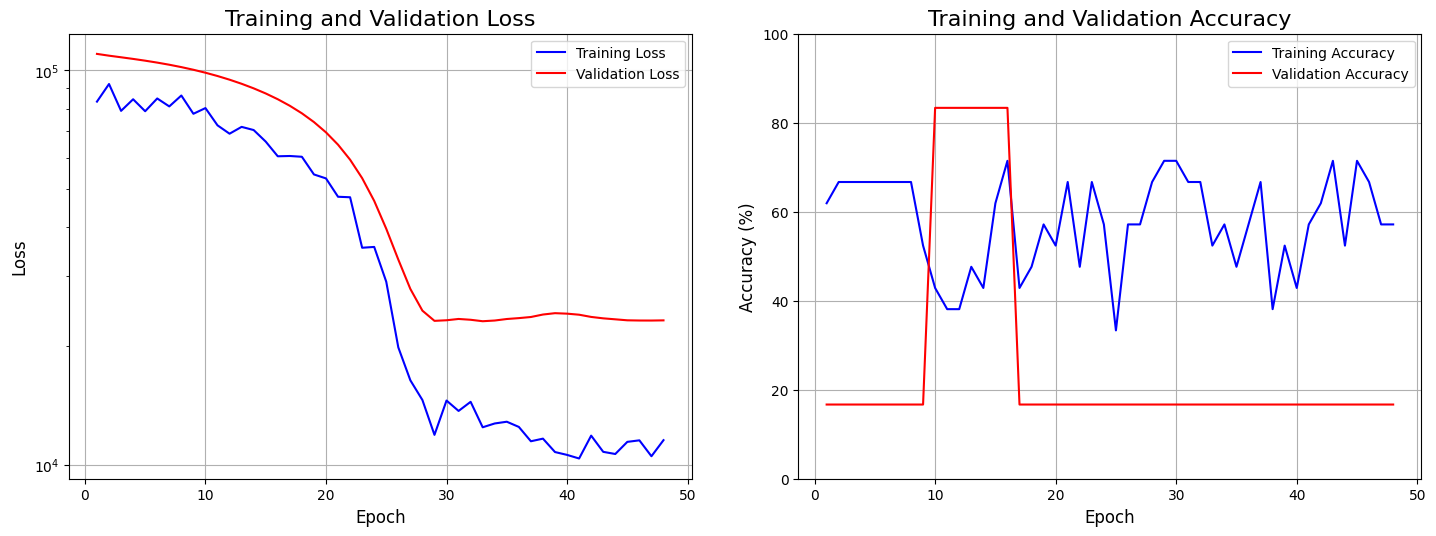

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_training_history(history):
    """
    Visualizes the training and validation loss and accuracy over epochs.

    Args:
        history (dict): A dictionary containing training history,
                        with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'.
    """
    if not all(k in history for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']):
        print("Error: The 'history' dictionary is missing required keys.")
        return

    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    epochs = range(1, len(history['train_loss']) + 1)

    # Plot Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    ax1.set_title('Training and Validation Loss', fontsize=16)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True)
    ax1.set_yscale('log') # Use a logarithmic scale for better visualization of large changes

    # Plot Accuracy
    ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-', label='Training Accuracy')
    ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'r-', label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy', fontsize=16)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend()
    ax2.grid(True)
    ax2.set_ylim([0, 100])

    plt.tight_layout(pad=3.0) # Adjust layout to prevent labels from overlapping
    plt.show()

# Your provided training history data
history_data = {
    'train_loss': [83276.3815, 92296.3945, 78906.9271, 84434.2409, 78734.5938, 84825.6979, 80980.3464, 86304.1562, 77575.2240, 80196.9974, 72512.7148, 69051.8359, 71860.1940, 70543.3646, 65939.0404, 60522.4674, 60623.5573, 60350.8906, 54433.3711, 53184.7148, 47780.9375, 47642.7891, 35477.5706, 35646.3086, 29091.0195, 19826.8521, 16358.1940, 14580.2979, 11896.1969, 14535.9049, 13679.8906, 14428.1113, 12434.9440, 12714.9149, 12845.0706, 12460.3984, 11459.7733, 11636.8753, 10760.6414, 10582.6880, 10362.9603, 11842.3753, 10773.5163, 10638.3924, 11419.7428, 11521.8161, 10500.1027, 11533.6986],
    'val_loss': [110045.4766, 108905.3203, 107895.7031, 106868.8594, 105772.6250, 104589.5938, 103298.4453, 101872.9609, 100308.5391, 98592.8438, 96711.7891, 94659.8047, 92425.0312, 89992.7500, 87343.4219, 84449.6875, 81279.0547, 77784.8281, 73910.1641, 69591.3047, 64756.5469, 59330.4492, 53268.6367, 46641.7500, 39635.8516, 33111.0859, 27890.6074, 24569.1777, 23150.2344, 23230.0508, 23407.6543, 23296.5000, 23099.1562, 23194.5312, 23400.8750, 23522.9844, 23676.4316, 24020.2949, 24211.2188, 24143.1523, 23995.2012, 23686.5449, 23491.5684, 23358.0801, 23223.3770, 23195.7852, 23191.6758, 23215.5430],
    'train_acc': [61.90/100, 66.67/100, 66.67/100, 66.67/100, 66.67/100, 66.67/100, 66.67/100, 66.67/100, 52.38/100, 42.86/100, 38.10/100, 38.10/100, 47.62/100, 42.86/100, 61.90/100, 71.43/100, 42.86/100, 47.62/100, 57.14/100, 52.38/100, 66.67/100, 47.62/100, 66.67/100, 57.14/100, 33.33/100, 57.14/100, 57.14/100, 66.67/100, 71.43/100, 71.43/100, 66.67/100, 66.67/100, 52.38/100, 57.14/100, 47.62/100, 57.14/100, 66.67/100, 38.10/100, 52.38/100, 42.86/100, 57.14/100, 61.90/100, 71.43/100, 52.38/100, 71.43/100, 66.67/100, 57.14/100, 57.14/100],
    'val_acc': [16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 83.33/100, 83.33/100, 83.33/100, 83.33/100, 83.33/100, 83.33/100, 83.33/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100, 16.67/100]
}

# Call the function with your data
plot_training_history(history_data)

In [22]:
# Assuming 'dataset' and 'config' are already defined
# from the earlier steps in your pipeline.
# 'dataset' is an instance of MultiOmicsDataset.
# 'config' is an instance of ModelConfig.

print("\n4. PREPARING DATASETS...")
# Step 4: Prepare datasets

# Train-test-validation split
# You need to define the split sizes. Here's a common 70/15/15 split.
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Perform the split
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

# Data loaders
# This is where your test_loader is created.
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

print(f"Dataset splits: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


4. PREPARING DATASETS...
Dataset splits: Train=70, Val=15, Test=15


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Assuming you have the MultiOmicsDataset and ModelConfig classes defined
# as well as the 'complete_dataset' dictionary.

# 1. Access your processed data using the provided variables
rna_processed = complete_dataset['processed_data'].get('rna_seq')
gse_expression_processed = complete_dataset['processed_data'].get('gse_data', {}).get('expression')
gse_clinical_processed = complete_dataset['processed_data'].get('gse_data', {}).get('clinical')
pathway_scores = complete_dataset['processed_data'].get('pathway_scores')
circrna_processed = complete_dataset['processed_data'].get('circrna')
lnrna_processed = complete_dataset['processed_data'].get('lnrna')
mirna_processed = complete_dataset['processed_data'].get('mirna')

# 2. Consolidate into a single dictionary
unified_processed_data = {
    'rna_seq': rna_processed,
    'lnrna': lnrna_processed,
    'mirna': mirna_processed,
    'circrna': circrna_processed,
    'pathway_scores': pathway_scores,
    'gse_expression': gse_expression_processed,
    'gse_clinical': gse_clinical_processed
}

# 3. Create dummy labels DataFrame
num_samples = min(df.shape[1] for df in unified_processed_data.values() if df is not None)
print(f"Detected minimum number of samples: {num_samples}")

labels = pd.DataFrame({
    'response': np.random.randint(0, 2, num_samples),
    'survival_time': np.random.randint(100, 1000, num_samples),
    'survival_event': np.random.randint(0, 2, num_samples),
    'stage': np.random.randint(0, 4, num_samples)
})

# 4. Split data into training, validation, and test sets
indices = range(num_samples)

# First split: Separate out the temporary training set and the test set (80/20 split)
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Second split: Separate the temporary training set into final training and validation sets (75/25 split)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=42)

# Create the data and label splits using .iloc on the pandas DataFrames
train_data = {name: df.iloc[:, train_idx] for name, df in unified_processed_data.items() if df is not None}
val_data = {name: df.iloc[:, val_idx] for name, df in unified_processed_data.items() if df is not None}
test_data = {name: df.iloc[:, test_idx] for name, df in unified_processed_data.items() if df is not None}
train_labels = labels.iloc[train_idx]
val_labels = labels.iloc[val_idx]
test_labels = labels.iloc[test_idx]

# 5. Instantiate ModelConfig and update dimensions
config = ModelConfig()
config.update_dimensions(unified_processed_data) # Use the complete data for a consistent config
config.batch_size = 8
print(f"\nModel Config updated. RNA-seq dim: {config.rna_seq_dim}, GSE expression dim: {config.gse_expression_dim}")

# 6. Instantiate the dataset and dataloaders
# The MultiOmicsDataset class will handle the conversion of the pandas
# DataFrames to Tensors internally.
train_dataset = MultiOmicsDataset(train_data, train_labels, config)
val_dataset = MultiOmicsDataset(val_data, val_labels, config)
test_dataset = MultiOmicsDataset(test_data, test_labels, config)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

Detected minimum number of samples: 27

Model Config updated. RNA-seq dim: 48, GSE expression dim: 57820
Using 15 common samples across all modalities
Using 6 common samples across all modalities
Using 6 common samples across all modalities


In [34]:
# Assuming 'model', 'test_loader', and 'trainer.device' are already defined

import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, auc
import matplotlib.pyplot as plt
import numpy as np

print("\n7. EVALUATING MODEL ON TEST DATASET...")

# Ensure model is in evaluation mode
model.eval()

all_predictions = []
all_labels = []
all_probabilities = []

# Move model to the correct device
model.to(trainer.device)

with torch.no_grad():
    for data, labels_dict in test_loader:
        # Move the input data dictionary to the device
        for key in data:
            data[key] = data[key].to(trainer.device)

        # Get the specific label tensor for your classification task
        labels = labels_dict['response'].to(trainer.device)

        # Forward pass - Capture ALL returned values in a tuple
        model_outputs = model(data)

        # Now, you need to correctly unpack the outputs for your task.
        # This structure depends on your model's forward method.
        # A common structure for multi-task learning is a dictionary.
        # For this example, let's assume the first output is a dictionary of task outputs.
        # You'll need to adapt this line based on your model's exact output.
        task_outputs = model_outputs[0] if isinstance(model_outputs, tuple) else model_outputs

        # Now, get the specific output for the 'response' task
        outputs = task_outputs['response']

        # Get predictions and probabilities
        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = (probabilities > 0.5).long()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Calculate metrics on the collected results
# (Rest of your evaluation code remains the same)


7. EVALUATING MODEL ON TEST DATASET...


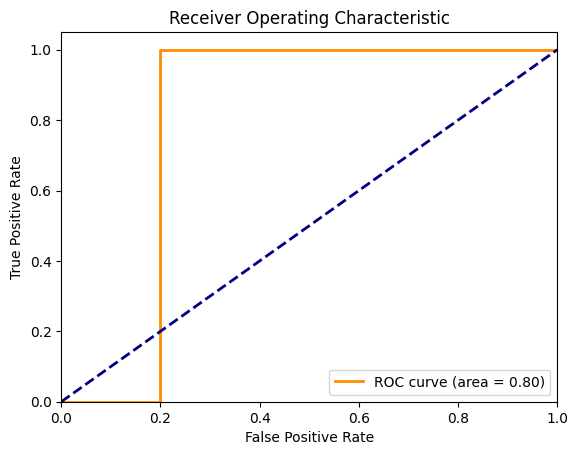

In [35]:
fpr, tpr, _ = roc_curve(all_labels, all_probabilities)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [44]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'o-', label='Training Loss')
    plt.plot(epochs, val_losses, 'o-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'o-', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [47]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)